In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from doc_chat.evaluation.pdf_util import write_pdf, read_pdf_info


In [2]:
# load the documents
pd_documents = pd.read_csv('../../data/single_topic_rag_evaluation_dataset/raw/documents.csv')
number_of_documents = pd_documents.shape[0]
print(f'Number of documents: {number_of_documents}')
pd_documents

Number of documents: 20


,index,source_url,text
0,0,https://enterthegungeon.fandom.com/wiki/Bullet...,Bullet Kin\nBullet Kin are one of the most com...
1,1,https://www.dropbox.com/scl/fi/ljtdg6eaucrbf1a...,---The Paths through the Underground/Underdark...
2,2,https://bytes-and-nibbles.web.app/bytes/stici-...,Semantic and Textual Inference Chatbot Interfa...
3,3,https://github.com/llmware-ai/llmware,llmware\n\nBuilding Enterprise RAG Pipelines w...
4,4,https://docs.marimo.io/recipes.html,Recipes\nThis page includes code snippets or “...
5,5,https://towardsdatascience.com/how-to-maximize...,How to Maximize Your Impact as a Data Scientis...
6,6,https://ec.europa.eu/commission/presscorner/de...,Why do we need to regulate the use of Artifici...
7,7,https://bg3.wiki/wiki/The_Emperor,The Emperor is a mind flayer who appears in Ba...
8,8,https://whattocook.substack.com/p/so-into-nort...,so into northern spain!\nour magical urban-plu...
9,9,https://dmtalkies.com/the-zone-of-interest-end...,‘The Zone Of Interest’ Ending Explained & Film...


In [4]:
# create pdf files from the documents
out_dir = '../../data/single_topic_rag_evaluation_dataset/processed/pdf'

# enable this to write the pdf files
# for index, row in pd_documents.iterrows():
#     text = row['text']
#     write_pdf(text, f"{out_dir}/document_{index}.pdf")

In [5]:
# read number of pages in each PDF file and add it to the DataFrame
for index, row in pd_documents.iterrows():
    pdf_info = read_pdf_info(f"{out_dir}/document_{index}.pdf")
    pd_documents.loc[index, 'num_pages'] = int(pdf_info['num_pages'])
    pd_documents.loc[index, 'total_word_count'] = int(pdf_info['total_word_count'])
    pd_documents.loc[index, 'avg_words_per_page'] = int(pdf_info['avg_words_per_page'])
    pd_documents.loc[index, 'total_char_count'] = int(pdf_info['total_char_count'])
    pd_documents.loc[index, 'avg_chars_per_page'] = int(pdf_info['avg_chars_per_page'])

pd_documents['num_pages'] = pd_documents['num_pages'].astype(int)
pd_documents

,index,source_url,text,num_pages,total_word_count,avg_words_per_page,total_char_count,avg_chars_per_page
0,0,https://enterthegungeon.fandom.com/wiki/Bullet...,Bullet Kin\nBullet Kin are one of the most com...,4,1846.0,461.0,10611.0,2652.0
1,1,https://www.dropbox.com/scl/fi/ljtdg6eaucrbf1a...,---The Paths through the Underground/Underdark...,2,471.0,235.0,2738.0,1369.0
2,2,https://bytes-and-nibbles.web.app/bytes/stici-...,Semantic and Textual Inference Chatbot Interfa...,9,3790.0,421.0,22119.0,2457.0
3,3,https://github.com/llmware-ai/llmware,llmware\n\nBuilding Enterprise RAG Pipelines w...,8,3017.0,377.0,20348.0,2543.0
4,4,https://docs.marimo.io/recipes.html,Recipes\nThis page includes code snippets or “...,5,1796.0,359.0,11262.0,2252.0
5,5,https://towardsdatascience.com/how-to-maximize...,How to Maximize Your Impact as a Data Scientis...,6,2443.0,407.0,14216.0,2369.0
6,6,https://ec.europa.eu/commission/presscorner/de...,Why do we need to regulate the use of Artifici...,14,5404.0,386.0,35381.0,2527.0
7,7,https://bg3.wiki/wiki/The_Emperor,The Emperor is a mind flayer who appears in Ba...,7,2974.0,424.0,17893.0,2556.0
8,8,https://whattocook.substack.com/p/so-into-nort...,so into northern spain!\nour magical urban-plu...,5,2045.0,409.0,11259.0,2251.0
9,9,https://dmtalkies.com/the-zone-of-interest-end...,‘The Zone Of Interest’ Ending Explained & Film...,5,2326.0,465.0,13469.0,2693.0


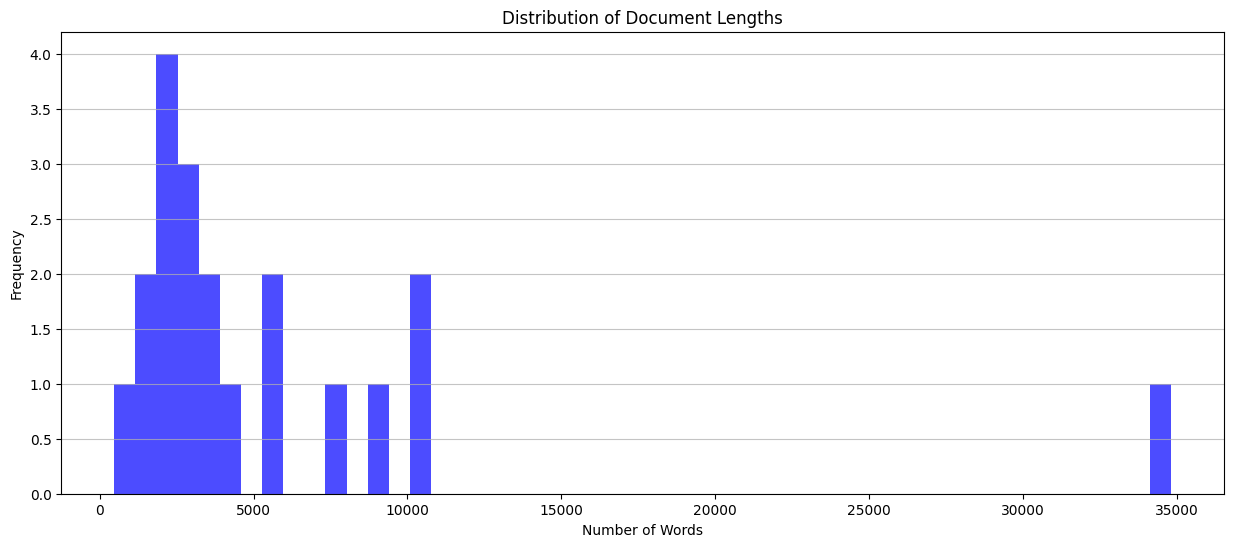

In [7]:
# plot the length of the documents
plt.figure(figsize=(15, 6))
plt.hist(pd_documents['total_word_count'], bins=50, color='blue', alpha=0.7)
plt.title('Distribution of Document Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [8]:

# write the DataFrame to a CSV file
pd_documents.to_csv('../../data/single_topic_rag_evaluation_dataset/processed/documents_processed.csv', index=False)